1. IMPORT THƯ VIỆN

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime
from scipy.stats import spearmanr, mannwhitneyu, kruskal

In [4]:
# Đọc dữ liệu
df = pd.read_csv("Cleaned_Data.csv", encoding="utf-8-sig")
print("Kích thước dữ liệu:", df.shape)

Kích thước dữ liệu: (1658, 10)


2. KIỂM TRA DỮ LIỆU


In [5]:
# Xem tên cột
print(df.columns.tolist())

['SoVaoVien', 'TenBenhNhan', 'NamSinh', 'GioiTinh', 'thoigianvaovien', 'thoigianravien', 'KetQua', 'NgayThucHien', 'MaICD Chính', 'MaICD Phụ']


In [6]:
# Xem 5 dòng đầu
df.head()

,SoVaoVien,TenBenhNhan,NamSinh,GioiTinh,thoigianvaovien,thoigianravien,KetQua,NgayThucHien,MaICD Chính,MaICD Phụ
0,24011828,An Thị Bình,1955,Nữ,KHÔNG XÁC ĐỊNH,KHÔNG XÁC ĐỊNH,19.08,11/5/2024 0:00,I50,I10
1,8006074,Bạch Hồng Oanh,1940,Nữ,KHÔNG XÁC ĐỊNH,KHÔNG XÁC ĐỊNH,427.80,10/29/2024 0:00,I50,I10
2,24012501,Bạch Thị Mai,1961,Nữ,KHÔNG XÁC ĐỊNH,KHÔNG XÁC ĐỊNH,168.30,11/18/2024 0:00,I50,I10
3,24008612,Bế Kim Hiêm,1968,Nam,KHÔNG XÁC ĐỊNH,KHÔNG XÁC ĐỊNH,67.18,8/23/2024 0:00,I50,I10
4,11005401,Bùi Bá Đản,1939,Nam,KHÔNG XÁC ĐỊNH,KHÔNG XÁC ĐỊNH,38.13,11/7/2024 0:00,I50,I10


In [7]:
# Kiểu dữ liệu và giá trị thiếu
print(df.dtypes)
print("\nSố lượng giá trị thiếu:")
print(df.isnull().sum())

SoVaoVien            int64
TenBenhNhan         object
NamSinh              int64
GioiTinh            object
thoigianvaovien     object
thoigianravien      object
KetQua             float64
NgayThucHien        object
MaICD Chính         object
MaICD Phụ           object
dtype: object

Số lượng giá trị thiếu:
SoVaoVien          0
TenBenhNhan        0
NamSinh            0
GioiTinh           0
thoigianvaovien    0
thoigianravien     0
KetQua             0
NgayThucHien       0
MaICD Chính        0
MaICD Phụ          0
dtype: int64


In [8]:
# Xem giá trị giới tính đang có
print(df["GioiTinh"].value_counts(dropna=False))
print(df["GioiTinh"].unique())

GioiTinh
Nam    1136
Nữ      522
Name: count, dtype: int64
['Nữ' 'Nam']


3. TIỀN XỬ LÝ DỮ LIỆU


In [9]:
# Đổi tên cột KetQua thành NT_proBNP
df = df.rename(columns={"KetQua": "NT_proBNP"})
print(df.columns.tolist())

['SoVaoVien', 'TenBenhNhan', 'NamSinh', 'GioiTinh', 'thoigianvaovien', 'thoigianravien', 'NT_proBNP', 'NgayThucHien', 'MaICD Chính', 'MaICD Phụ']


In [10]:
# Chuyển các cột số về numeric
df["NamSinh"] = pd.to_numeric(df["NamSinh"], errors="coerce")
df["NT_proBNP"] = pd.to_numeric(df["NT_proBNP"], errors="coerce")

In [11]:
# Loại bỏ các dòng thiếu biến quan trọng
df = df.dropna(subset=["NamSinh", "GioiTinh", "NT_proBNP"])
print("Kích thước dữ liệu sau khi loại thiếu:", df.shape)

Kích thước dữ liệu sau khi loại thiếu: (1658, 10)


In [12]:
# Chuẩn hóa giới tính
df["GioiTinh"] = df["GioiTinh"].astype(str).str.strip()

df["GioiTinh"] = df["GioiTinh"].replace({
    "Nu": "Nữ",
    "nu": "Nữ",
    "NỮ": "Nữ",
    "nữ": "Nữ",
    "Nam ": "Nam",
    "nam": "Nam"
})

print(df["GioiTinh"].value_counts(dropna=False))

GioiTinh
Nam    1136
Nữ      522
Name: count, dtype: int64


4. TẠO BIẾN MỚI


In [13]:
# Tạo tuổi từ năm sinh
current_year = datetime.now().year
df["Tuoi"] = current_year - df["NamSinh"]

print(df[["NamSinh", "Tuoi"]].head())

   NamSinh  Tuoi
0     1955    71
1     1940    86
2     1961    65
3     1968    58
4     1939    87


In [14]:
# Tạo nhóm tuổi
bins = [59, 69, 79, 89, 120]
labels = ["60-69", "70-79", "80-89", "90+"]

df["NhomTuoi"] = pd.cut(df["Tuoi"], bins=bins, labels=labels)

print(df["NhomTuoi"].value_counts(dropna=False))

NhomTuoi
80-89    687
70-79    518
60-69    192
90+      192
NaN       69
Name: count, dtype: int64


In [15]:
# Tạo biến log của NT-proBNP
df["NT_log"] = np.log1p(df["NT_proBNP"])

print(df[["NT_proBNP", "NT_log"]].head())

   NT_proBNP    NT_log
0      19.08  2.999724
1     427.80  6.060991
2     168.30  5.131672
3      67.18  4.222151
4      38.13  3.666889


5. EDA

In [16]:
# Thống kê mô tả tổng quan
print(df[["Tuoi", "NT_proBNP", "NT_log"]].describe())

              Tuoi     NT_proBNP       NT_log
count  1658.000000   1658.000000  1658.000000
mean     78.887214    500.824590     4.986260
std      10.260220   1902.492728     1.423153
min      18.000000     10.000000     2.397895
25%      73.000000     54.275000     4.012320
50%      81.000000    129.450000     4.870986
75%      86.000000    371.125000     5.919230
max     101.000000  35000.000000    10.463132


In [17]:
# Thống kê theo giới tính
print(df.groupby("GioiTinh")[["NT_proBNP", "NT_log"]].describe())

         NT_proBNP                                                          \
             count        mean          std   min     25%     50%      75%   
GioiTinh                                                                     
Nam         1136.0  578.042368  2231.724903  10.0  50.605  136.95  440.100   
Nữ           522.0  332.779770   787.358390  10.0  57.115  113.95  249.125   

                   NT_log                                                    \
              max   count      mean       std       min       25%       50%   
GioiTinh                                                                      
Nam       35000.0  1136.0  5.040939  1.491976  2.397895  3.943618  4.926891   
Nữ        11248.0   522.0  4.867266  1.253585  2.397895  4.062424  4.744463   

                               
               75%        max  
GioiTinh                       
Nam       6.089271  10.463132  
Nữ        5.521960   9.328035  


In [18]:
# Thống kê theo nhóm tuổi
print(df.groupby("NhomTuoi")[["NT_proBNP", "NT_log"]].describe())

         NT_proBNP                                                            \
             count        mean          std   min      25%      50%      75%   
NhomTuoi                                                                       
60-69        192.0  354.646354  2534.208584  10.0  32.0175   61.545  176.050   
70-79        518.0  431.839479  1785.755995  10.0  44.0725  101.200  307.400   
80-89        687.0  511.061339  1331.403151  10.0  76.4200  163.400  420.100   
90+          192.0  731.005104  1889.319097  10.0  96.6150  251.900  665.975   

                  NT_log                                                    \
              max  count      mean       std       min       25%       50%   
NhomTuoi                                                                     
60-69     35000.0  192.0  4.342111  1.333352  2.397895  3.497023  4.135886   
70-79     35000.0  518.0  4.798958  1.420009  2.397895  3.808263  4.626930   
80-89     23455.0  687.0  5.248119  1.289125  2.3

/tmp/ipykernel_1046/3759268106.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("NhomTuoi")[["NT_proBNP", "NT_log"]].describe())


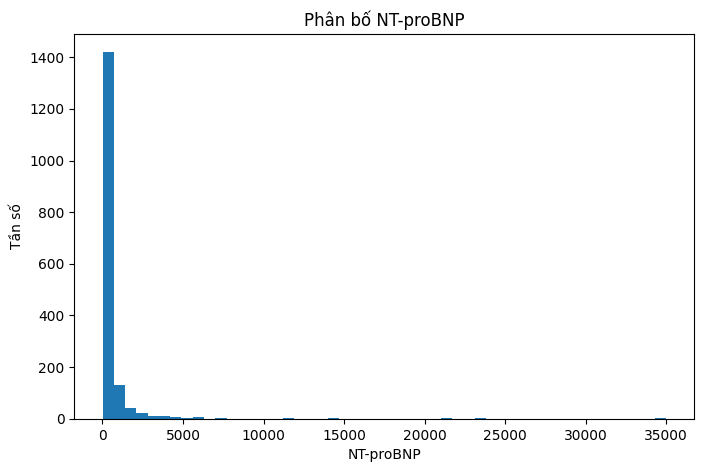

In [19]:
# Histogram NT_proBNP gốc
plt.figure(figsize=(8,5))
plt.hist(df["NT_proBNP"], bins=50)
plt.title("Phân bố NT-proBNP")
plt.xlabel("NT-proBNP")
plt.ylabel("Tần số")
plt.show()

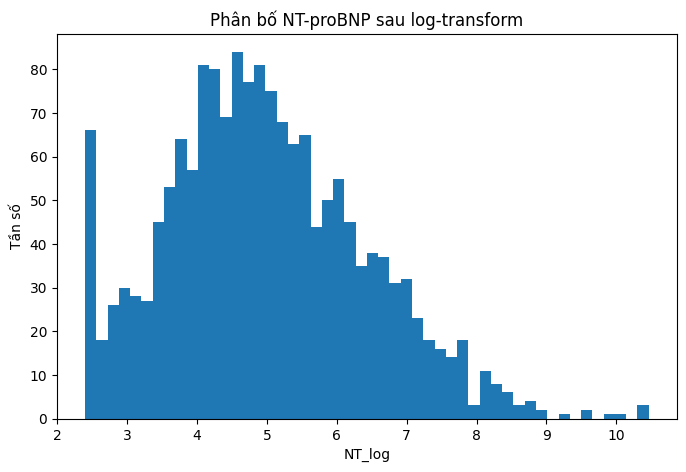

In [20]:
# Histogram NT_log
plt.figure(figsize=(8,5))
plt.hist(df["NT_log"], bins=50)
plt.title("Phân bố NT-proBNP sau log-transform")
plt.xlabel("NT_log")
plt.ylabel("Tần số")
plt.show()

<Figure size 800x500 with 0 Axes>

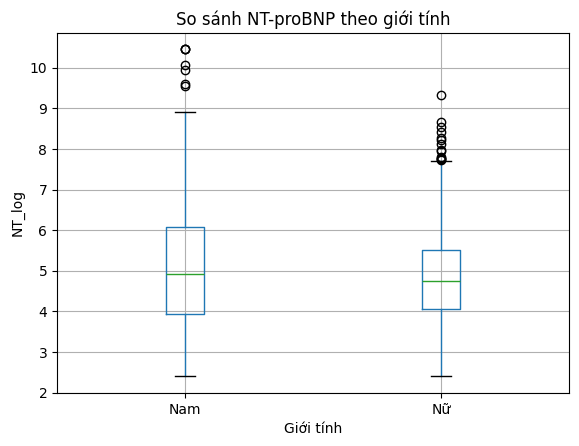

In [21]:
# Boxplot theo giới tính
plt.figure(figsize=(8,5))
df.boxplot(column="NT_log", by="GioiTinh")
plt.title("So sánh NT-proBNP theo giới tính")
plt.suptitle("")
plt.xlabel("Giới tính")
plt.ylabel("NT_log")
plt.show()

<Figure size 800x500 with 0 Axes>

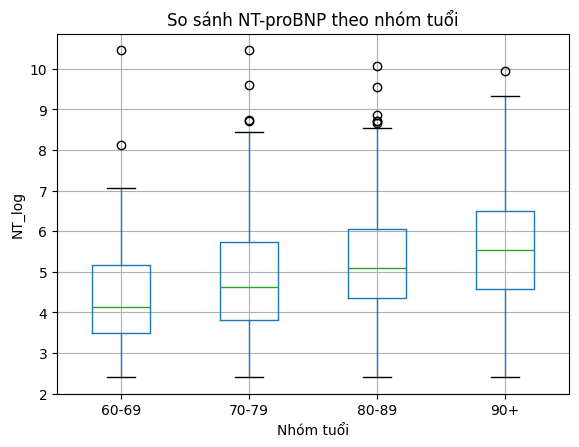

In [22]:
# Boxplot theo nhóm tuổi
plt.figure(figsize=(8,5))
df.boxplot(column="NT_log", by="NhomTuoi")
plt.title("So sánh NT-proBNP theo nhóm tuổi")
plt.suptitle("")
plt.xlabel("Nhóm tuổi")
plt.ylabel("NT_log")
plt.show()

6. KIỂM ĐỊNH THỐNG KÊ

In [23]:
# Spearman: tuổi và NT_log
corr, p1 = spearmanr(df["Tuoi"], df["NT_log"], nan_policy="omit")

print("Spearman correlation:", corr)
print("Spearman p-value:", p1)

Spearman correlation: 0.31485301640209984
Spearman p-value: 1.783036716724663e-39


In [24]:
# Mann-Whitney U: Nam và Nữ
group_nam = df[df["GioiTinh"] == "Nam"]["NT_log"].dropna()
group_nu = df[df["GioiTinh"] == "Nữ"]["NT_log"].dropna()

stat2, p2 = mannwhitneyu(group_nam, group_nu)

print("Mann-Whitney statistic:", stat2)
print("Mann-Whitney p-value:", p2)

Mann-Whitney statistic: 315547.0
Mann-Whitney p-value: 0.0353737213500613


In [25]:
# Kruskal-Wallis theo nhóm tuổi
groups = [
    g["NT_log"].dropna().values
    for _, g in df.groupby("NhomTuoi")
    if len(g["NT_log"].dropna()) > 0
]

stat3, p3 = kruskal(*groups)

print("Kruskal-Wallis statistic:", stat3)
print("Kruskal-Wallis p-value:", p3)

Kruskal-Wallis statistic: 115.69735738547529
Kruskal-Wallis p-value: 6.515474574369621e-25


/tmp/ipykernel_1046/1782224978.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, g in df.groupby("NhomTuoi")


In [26]:
# In gọn kết quả cuối cùng
print("=== KẾT QUẢ KIỂM ĐỊNH ===")
print(f"Spearman p-value: {p1}")
print(f"Mann-Whitney p-value: {p2}")
print(f"Kruskal-Wallis p-value: {p3}")

=== KẾT QUẢ KIỂM ĐỊNH ===
Spearman p-value: 1.783036716724663e-39
Mann-Whitney p-value: 0.0353737213500613
Kruskal-Wallis p-value: 6.515474574369621e-25


7. XUẤT FILE CHO POWER BI


In [27]:
df.to_csv("Final_Data.csv", index=False, encoding="utf-8-sig")
print("Đã lưu file Final_Data.csv")

Đã lưu file Final_Data.csv


XÂY DỰNG MÔ HÌNH

In [28]:
# ===============================
# 1. TẠO BIẾN MỤC TIÊU
# ===============================

age_group_cols = [
    col for col in df_model.columns
    if col.startswith('Age_group_')
]

features = ['Age', 'Gender_encoded'] + age_group_cols

X = df_model[features]
y = df_model['NTproBNP_group']

print(X.head())
df['NTproBNP_group'] = df['NT_proBNP'].apply(
    lambda x: 1 if x > 300 else 0
)

df['NTproBNP_group'].value_counts()

,count
NTproBNP_group,
0,1188
1,470


In [30]:
# ===============================
# 2. MÃ HOÁ GIỚI TÍNH
# ===============================

# Sửa 'Gender' thành 'GioiTinh' để khớp với dữ liệu thực tế
df['Gender_encoded'] = df['GioiTinh'].map({
    'Nam': 1,
    'Nữ': 0
})

print(df[['GioiTinh', 'Gender_encoded']].head())

  GioiTinh  Gender_encoded
0       Nữ               0
1       Nữ               0
2       Nữ               0
3      Nam               1
4      Nam               1


In [32]:
# ===============================
# 3. MÃ HOÁ NHÓM TUỔI CÓ SẴN
# ===============================

# Sửa 'Age_group' thành 'NhomTuoi' để khớp với dữ liệu đã tạo
df_model = pd.get_dummies(
    df,
    columns=['NhomTuoi'],
    drop_first=True
)

print(df_model.columns.tolist())

['SoVaoVien', 'TenBenhNhan', 'NamSinh', 'GioiTinh', 'thoigianvaovien', 'thoigianravien', 'NT_proBNP', 'NgayThucHien', 'MaICD Chính', 'MaICD Phụ', 'Tuoi', 'NT_log', 'NTproBNP_group', 'Gender_encoded', 'NhomTuoi_70-79', 'NhomTuoi_80-89', 'NhomTuoi_90+']


In [34]:
# ===============================
# 4. CHỌN BIẾN ĐẦU VÀO
# ===============================

# Sửa tiền tố thành 'NhomTuoi_' để khớp với kết quả pd.get_dummies trước đó
age_group_cols = [
    col for col in df_model.columns
    if col.startswith('NhomTuoi_')
]

# Sửa 'Age' thành 'Tuoi'
features = ['Tuoi', 'Gender_encoded'] + age_group_cols

X = df_model[features]
y = df_model['NTproBNP_group']

print("Các biến đầu vào:", features)
print(X.head())

Các biến đầu vào: ['Tuoi', 'Gender_encoded', 'NhomTuoi_70-79', 'NhomTuoi_80-89', 'NhomTuoi_90+']
   Tuoi  Gender_encoded  NhomTuoi_70-79  NhomTuoi_80-89  NhomTuoi_90+
0    71               0            True           False         False
1    86               0           False            True         False
2    65               0           False           False         False
3    58               1           False           False         False
4    87               1           False            True         False


In [35]:
# ===============================
# 5. CHIA TẬP TRAIN / TEST
# ===============================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
# ===============================
# 6. LOGISTIC REGRESSION
# ===============================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("LOGISTIC REGRESSION")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))
print("Classification Report:")
print(classification_report(y_test, y_pred_log))

LOGISTIC REGRESSION
Accuracy: 0.7168674698795181
Confusion Matrix:
[[238   0]
 [ 94   0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.72      1.00      0.84       238
           1       0.00      0.00      0.00        94

    accuracy                           0.72       332
   macro avg       0.36      0.50      0.42       332
weighted avg       0.51      0.72      0.60       332



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [37]:
# ===============================
# 7. DECISION TREE
# ===============================

from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("DECISION TREE")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))
print("Classification Report:")
print(classification_report(y_test, y_pred_tree))

DECISION TREE
Accuracy: 0.7228915662650602
Confusion Matrix:
[[237   1]
 [ 91   3]]
Classification Report:
              precision    recall  f1-score   support

           0       0.72      1.00      0.84       238
           1       0.75      0.03      0.06        94

    accuracy                           0.72       332
   macro avg       0.74      0.51      0.45       332
weighted avg       0.73      0.72      0.62       332



In [38]:
# ===============================
# 8. RANDOM FOREST
# ===============================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("RANDOM FOREST")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST
Accuracy: 0.7319277108433735
Confusion Matrix:
[[238   0]
 [ 89   5]]
Classification Report:
              precision    recall  f1-score   support

           0       0.73      1.00      0.84       238
           1       1.00      0.05      0.10        94

    accuracy                           0.73       332
   macro avg       0.86      0.53      0.47       332
weighted avg       0.80      0.73      0.63       332



In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Mô hình': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log, zero_division=0),
        precision_score(y_test, y_pred_tree, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log, zero_division=0),
        recall_score(y_test, y_pred_tree, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_log, zero_division=0),
        f1_score(y_test, y_pred_tree, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0)
    ]
})

results

,Mô hình,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.716867,0.00,0.000000,0.000000
1,Decision Tree,0.722892,0.75,0.031915,0.061224
2,Random Forest,0.731928,1.00,0.053191,0.101010
